# 03 — Classical Inference

**Chapter 5 companion.** Do first-year retention rates differ by institutional
control? The question is simple, but a defensible answer needs three things the
usual t-test skips: tests that tolerate unequal variances and skew, a correction for
making several comparisons, and an effect size, because with thousands of
institutions almost any difference is statistically significant.

The notebook ends with the ecological point that matters most for policy: the
average institution and the average student give different answers.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet` |
| Outcome | `RET_PCF`: full-time retention rate, fall 2022 cohort retained to fall 2023 (`EF2023D`) |
| Methods | Welch ANOVA, Kruskal-Wallis, pairwise Mann-Whitney with Holm correction, Cliff's delta, bootstrap CIs, a permutation test, cohort-weighted vs institution-weighted means |

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. The comparison set

Retention is compared among four-year institutions (`ICLEVEL` 1), where the three
controls overlap enough in mission to make the comparison meaningful. Rates from
very small cohorts are too noisy to compare, so cohorts under 10 students are
excluded. Notebook 04 shows the principled alternative to such a hard cutoff.

In [3]:
four = inst[(inst["ICLEVEL"] == 1) & inst["RET_PCF"].notna() & (inst["RRFTCTA"] >= 10)].copy()
groups = {label: g["RET_PCF"].to_numpy(dtype=float) for label, g in four.groupby("CONTROL_LABEL")}

four.groupby("CONTROL_LABEL")["RET_PCF"].describe()[["count", "mean", "std", "25%", "50%", "75%"]]

,count,mean,std,25%,50%,75%
CONTROL_LABEL,,,,,,
Private for-profit,92.000,63.685,20.118,52.000,64.500,78.000
Private not-for-profit,"1,136.000",75.018,14.434,67.000,77.000,85.000
Public,627.000,74.142,11.778,68.000,75.000,81.000


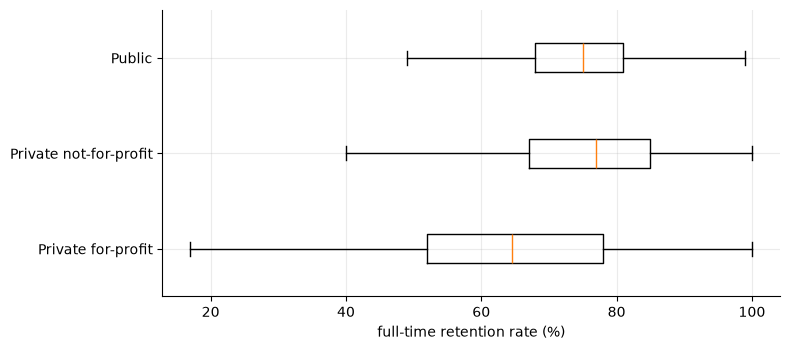

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.boxplot(list(groups.values()), orientation="horizontal", showfliers=False)
ax.set_yticks(range(1, len(groups) + 1), list(groups))
ax.set(xlabel="full-time retention rate (%)")
save("03_retention_by_control")

## 2. Omnibus tests

The standard one-way ANOVA assumes equal variances. Levene's test checks that
assumption; Welch's ANOVA drops it. Kruskal-Wallis tests whether one group tends to
produce larger values than another, and needs neither normality nor equal variances.

In [5]:
from scipy import stats
from statsmodels.stats.oneway import anova_oneway

levene = stats.levene(*groups.values(), center="median")
welch = anova_oneway(list(groups.values()), use_var="unequal")
kruskal = stats.kruskal(*groups.values())

pd.DataFrame({
    "statistic": [levene.statistic, welch.statistic, kruskal.statistic],
    "p-value": [levene.pvalue, welch.pvalue, kruskal.pvalue],
}, index=["Levene (Brown-Forsythe)", "Welch ANOVA", "Kruskal-Wallis"])

,statistic,p-value
Levene (Brown-Forsythe),27.056,0.000
Welch ANOVA,14.198,0.000
Kruskal-Wallis,35.275,0.000


## 3. Pairwise comparisons with Holm correction and effect sizes

Three pairwise tests at alpha = 0.05 each give roughly a 14% chance of at least one
false positive. Holm's step-down procedure controls that family-wise rate and is
uniformly more powerful than Bonferroni. Cliff's delta reports the effect: the
probability that a random institution from the first group has higher retention than
one from the second, minus the reverse. Its conventional thresholds are 0.147
(small), 0.33 (medium), and 0.474 (large).

In [6]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(groups, 2):
    test = stats.mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    low, high = iu.bootstrap_ci(lambda x, y: np.median(x) - np.median(y),
                                groups[a], groups[b], n_boot=2000, seed=SEED)
    rows.append({"comparison": f"{a}  vs  {b}", "median difference": np.median(groups[a]) - np.median(groups[b]),
                 "95% CI low": low, "95% CI high": high,
                 "Cliff's delta": iu.cliffs_delta(groups[a], groups[b]), "raw p": test.pvalue})

pairwise = pd.DataFrame(rows)
pairwise["Holm p"] = multipletests(pairwise["raw p"], method="holm")[1]
pairwise

,comparison,median difference,95% CI low,95% CI high,Cliff's delta,raw p,Holm p
0,Private for-profit vs Private not-for-profit,-12.500,-15.000,-6.000,-0.344,0.000,0.000
1,Private for-profit vs Public,-10.500,-13.000,-4.488,-0.316,0.000,0.000
2,Private not-for-profit vs Public,2.000,0.000,3.000,0.073,0.011,0.011


Read the effect sizes before the p-values. All three comparisons survive the Holm
correction, but they are not alike. For-profit institutions differ from both
nonprofits and publics by a medium effect (|delta| near 0.33). Nonprofits and
publics differ by a delta of about 0.07, well below the 0.147 threshold for even a
small effect: a detectable difference of no practical size, found only because the
groups are large. Even the medium effects leave heavy overlap, so many for-profit
institutions retain better than many nonprofits.

## 4. A permutation test of the mean difference

The permutation test makes no distributional assumption at all. Under the null
hypothesis the control labels are exchangeable, so shuffling them generates the null
distribution of the difference directly. It tests a difference in means, which is a
different null hypothesis from the Mann-Whitney test above.

public minus private nonprofit: -0.88 points; permutation p = 0.2016


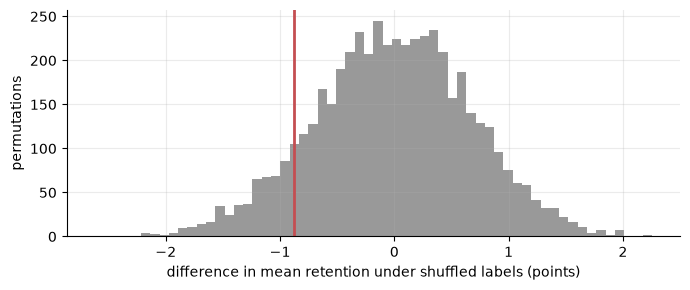

In [7]:
pub = groups["Public"]
npf = groups["Private not-for-profit"]
observed = pub.mean() - npf.mean()
pooled = np.concatenate([pub, npf])

null = np.empty(5000)
for i in range(null.size):
    perm = rng.permutation(pooled)
    null[i] = perm[: pub.size].mean() - perm[pub.size:].mean()

p_perm = (np.sum(np.abs(null) >= abs(observed)) + 1) / (null.size + 1)
print(f"public minus private nonprofit: {observed:+.2f} points; permutation p = {p_perm:.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(null, bins=60, color="#999999")
ax.axvline(observed, color="#C44E52", lw=2)
ax.set(xlabel="difference in mean retention under shuffled labels (points)", ylabel="permutations")
save("03_permutation_null")

Here the two tests disagree. Mann-Whitney calls the nonprofit-public difference
significant, while the permutation test on means does not, because they ask different
questions: whether one distribution tends to sit higher, and whether the means
differ. With a delta of 0.07, neither result supports a substantive claim.

## 5. The average institution versus the average student

Every test above weights each institution equally, so a college with 40 first-year
students counts as much as one with 8,000. Weighting by the adjusted retention
cohort (`RRFTCTA`) answers a different question: what happens to the typical
student. The two answers differ whenever retention is correlated with size, which is
the ecological fallacy made concrete.

In [8]:
def weighted(g):
    return pd.Series({
        "institutions": len(g),
        "students in cohort": g["RRFTCTA"].sum(),
        "institution-weighted mean": g["RET_PCF"].mean(),
        "student-weighted mean": np.average(g["RET_PCF"], weights=g["RRFTCTA"]),
    })


ecological = four.groupby("CONTROL_LABEL")[["RET_PCF", "RRFTCTA"]].apply(weighted)
ecological["gap (student - institution)"] = (
    ecological["student-weighted mean"] - ecological["institution-weighted mean"])
ecological

,institutions,students in cohort,institution-weighted mean,student-weighted mean,gap (student - institution)
CONTROL_LABEL,,,,,
Private for-profit,92.000,"24,252.000",63.685,61.133,-2.552
Private not-for-profit,"1,136.000","488,661.000",75.018,81.757,6.739
Public,627.000,"1,078,708.000",74.142,82.057,7.915


In [9]:
rho = stats.spearmanr(np.log10(four["RRFTCTA"]), four["RET_PCF"])
print(f"Spearman correlation of cohort size with retention: {rho.statistic:.2f}")

Spearman correlation of cohort size with retention: 0.35


Overall, retention rises with cohort size, and weighting by students raises the
public and nonprofit means by 7 to 8 points. For-profits move the other way: their
largest cohorts retain worse than their small ones. The public and nonprofit ranking
also flips. The typical nonprofit institution retains slightly better than the
typical public, while the typical student at a public retains slightly better than
one at a nonprofit.

Both statements are true; they answer different questions. "Public institutions
retain X% of their students" calls for the student-weighted figure. "The typical
public institution retains X%" calls for the institution-weighted one.

## Exercises

1. Repeat the pairwise table for part-time retention (`RET_PCP`). Which effect sizes
   change sign or magnitude, and how many institutions drop out for lack of a
   part-time cohort?
2. Replace the cohort-size cutoff of 10 with 30. How much do the Cliff's deltas move?
3. Run the permutation test on student-weighted means. What exactly is being
   permuted, and is exchangeability still plausible?